在这个模块里面,中国目前存在不同的股票板块  
A股  
- 上交所主板：大盘蓝筹、成熟期企业为主，国企/央企集中  
- 深交所主板：2021年深市原"中小板"并入主板后，现在深交所只剩主板,以民企和创新型企业为主  
- 科创板（上交所）：硬科技属性企业，2019年设立，注册制试点  
- 创业板（深交所）：成长型创新创业企业，2009年设立  
- 北交所：脱胎于新三板，服务更早期、更小的创新型中小企业    
  
港股  
&nbsp; &nbsp; &nbsp; &nbsp; 主板、创业板（GEM）

由于中国的主流指数编撰存在相互嵌套的现象,所以我们应该找出于金价最相关的指数.  
但是存在的问题是,2019年以后,中国设立了科创板,作为上证指数的子集,而指数调换以后进一步加强了科技创新的权重,可能对指数的预测有 **新的变化**.  
并且观察主要的黄金股份,它们在上海和深圳交易所都有上市,因此以单独的市场指数来表示都不准确

在Kaggle的一个预测金价的项目中,项目提供的数据集是以标普500代表美国的宽基指数,虽然中国的沪深300与标普500组成不太一样,但是以沪深300为基础的指数,其覆盖面大概占股市的60%,而标普占据了80%,代表性沪深300更弱.  
我也会采取A500,这个指数更加接近标普500,将各方的龙头编入进来力求各行业均衡.  
此外,我自己也会编制一个新的指数,叫做黄金概念,详情见[黄金概念指数编制](../../doc/黄金概念指数编撰规则.md)

In [1]:
import yfinance as yf
import pandas as pd
from pandas import DataFrame as df

In [2]:
CSI_300_index = yf.download('000300.SS',start='2008-05-01',end='2026-7-23')
CSI_300_index.to_csv('../../data/CSI_300.csv')

[*********************100%***********************]  1 of 1 completed


In [3]:
CSI_300_index = pd.read_csv('../../data/CSI_300.csv',skiprows=[0,2])
CSI_300_index.head()

,Ticker,000300.SS,000300.SS.1,000300.SS.2,000300.SS.3,000300.SS.4
0,2021-03-11,5128.220215,5138.410156,5020.580078,5024.560059,189600
1,2021-03-12,5146.379883,5153.669922,5086.819824,5153.669922,201000
2,2021-03-15,5035.540039,5120.879883,4992.399902,5116.120117,204200
3,2021-03-16,5079.359863,5084.310059,5009.950195,5054.410156,161400
4,2021-03-17,5100.859863,5123.549805,5020.129883,5062.770020,149200


这里遇到了个问题,查看了下YahooFinance,最早的数据就是21年的.必须换一个数据库,采用akshare提取数据

In [4]:
#pip install akshare

In [5]:
import akshare as ak
CSI_300_index=ak.stock_zh_index_daily(symbol='sh000300')
# ak.stock_
#CSI_300_index.to_csv('../../data/CSI_300_actual')
CSI_300_index.head()


,date,open,high,low,close,volume
0,2002-01-04,1316.455,1316.455,1316.455,1316.455,0
1,2002-01-07,1302.084,1302.084,1302.084,1302.084,0
2,2002-01-08,1292.714,1292.714,1292.714,1292.714,0
3,2002-01-09,1272.645,1272.645,1272.645,1272.645,0
4,2002-01-10,1281.261,1281.261,1281.261,1281.261,0


只选取2008年5月1号以后的数据

In [6]:
CSI_300_index.dtypes

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

In [7]:
CSI_300_index['date'] = pd.to_datetime(CSI_300_index['date'])
CSI_300_index=CSI_300_index[CSI_300_index['date']>='2008-05-01']
CSI_300_index = CSI_300_index.set_index('date')
CSI_300_index.to_csv('../../data/CSI_300.csv')
CSI_300_index.head()

,open,high,low,close,volume
date,,,,,
2008-05-05,4015.212,4061.472,3972.561,4055.779,6253407300
2008-05-06,4021.073,4075.575,3961.344,4010.888,5845928000
2008-05-07,3986.129,4042.407,3821.107,3821.319,5445770600
2008-05-08,3774.044,3926.004,3761.280,3925.041,4405566800
2008-05-09,3960.886,3973.058,3806.519,3878.924,5365592900


因为中美的法定假期不一样,开始时间不一样,之后要对多个不同的数据取交集  
>如果中国股市在春节等长假中休市,把时间拉长是否会有较大的影响?  
>应该只会在画图时候缺失,在作为训练数据时由于取交集会被忽视掉.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='date', ylabel='close'>

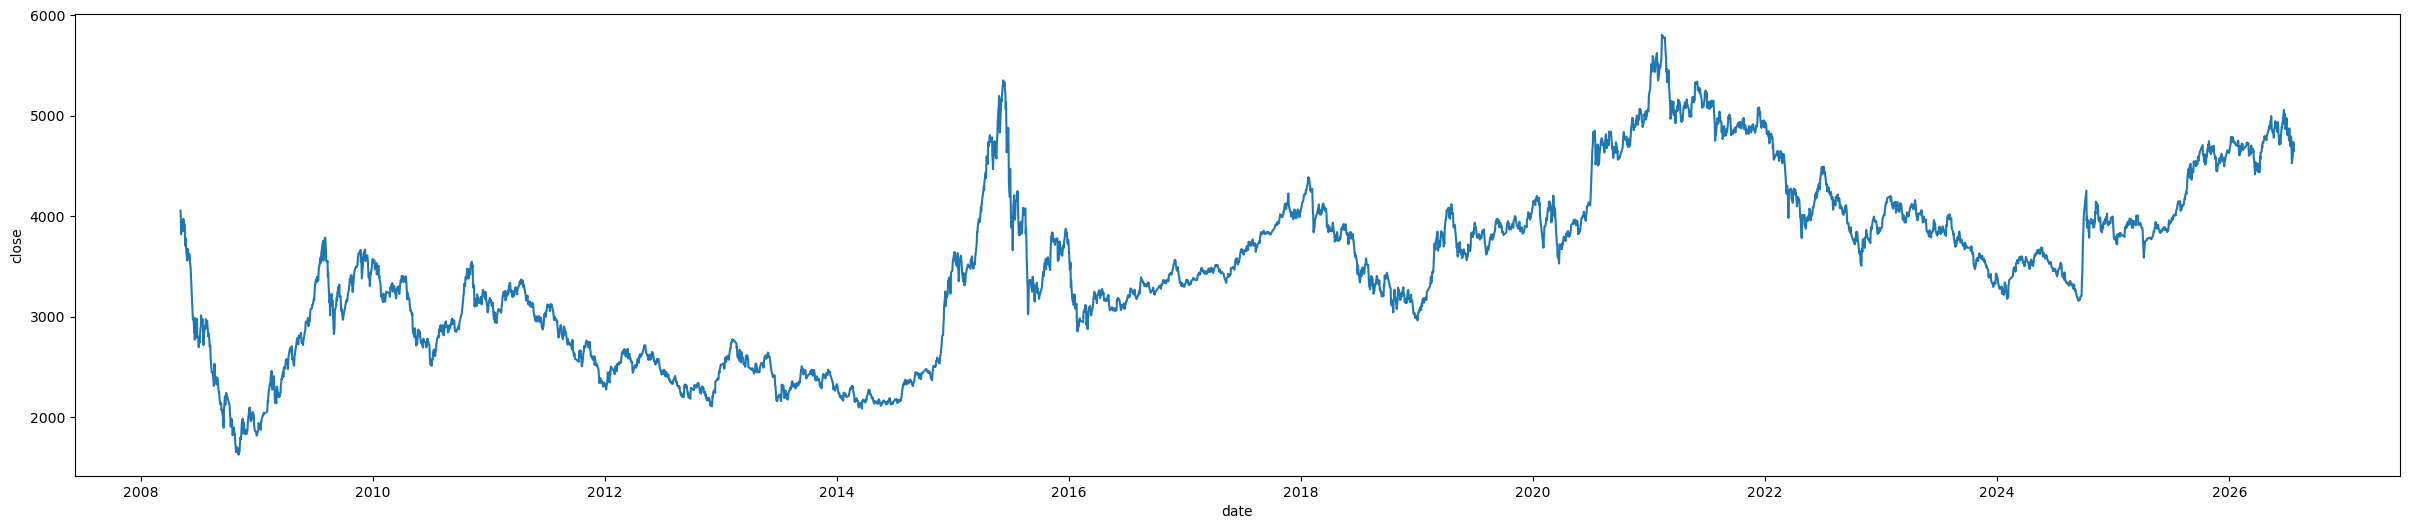

In [9]:
plt.figure(figsize=(30,6))
sns.lineplot(CSI_300_index,x='date',y='close')

In [10]:
CSI_300_index.to_csv('../../data/CSI_300_actual_alter')

In [11]:
A500_index=ak.stock_zh_index_daily(symbol='sh000510')
A500_index.head()

,date,open,high,low,close,volume
0,2005-01-04,995.421,995.421,982.745,984.640,785673530
1,2005-01-05,983.552,999.173,983.477,996.035,858145250
2,2005-01-06,996.750,996.750,984.334,987.063,723711059
3,2005-01-07,986.328,999.624,984.026,988.331,831145398
4,2005-01-10,987.780,997.697,984.353,997.697,698390802


In [12]:
A500_index['date']=pd.to_datetime(A500_index['date'])
A500_index = A500_index[A500_index['date']>='2008-5-1']
A500_index = A500_index.set_index('date')
A500_index.head()

,open,high,low,close,volume
date,,,,,
2008-05-05,3931.689,3976.044,3904.271,3972.868,7581219851
2008-05-06,3938.700,3984.624,3883.115,3933.668,7224664870
2008-05-07,3909.694,3959.834,3749.700,3749.700,6743682467
2008-05-08,3703.252,3850.233,3703.252,3850.233,5564718075
2008-05-09,3883.296,3883.621,3754.082,3811.461,6695654395


In [13]:
A500_index.to_csv('../../data/A_500.csv')

<Axes: xlabel='date', ylabel='close'>

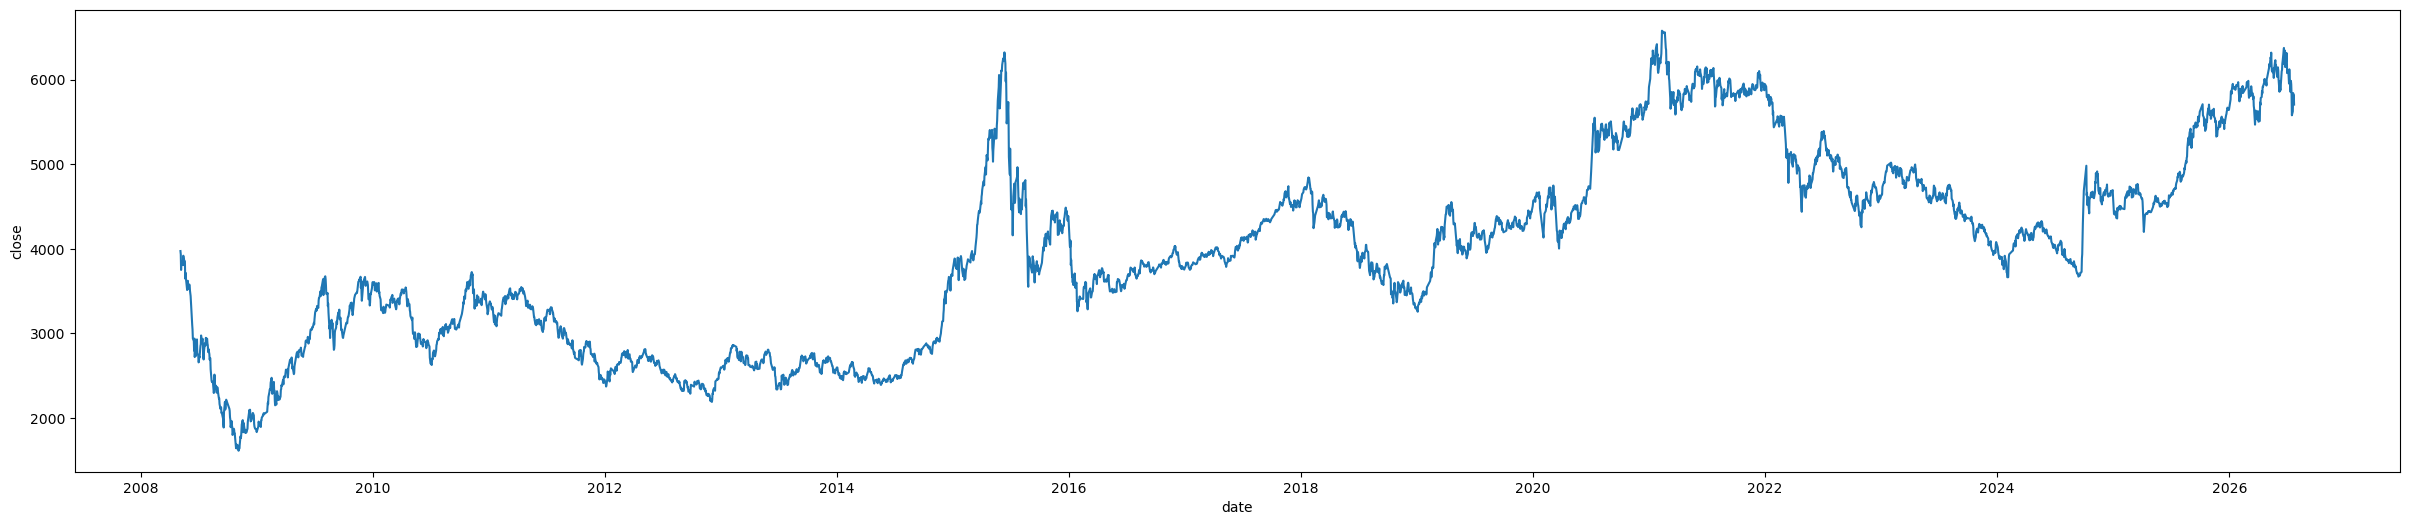

In [14]:
plt.figure(figsize=(30,6))
sns.lineplot(A500_index,x='date',y='close')

In [15]:
#此为有色金属
metal_index=ak.fund_etf_hist_sina(symbol='sh000819')
metal_index.head()
# metal_index.to_csv('../../data/metal_index.csv')

,date,prevclose,open,high,low,close,volume,amount
0,2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
1,2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2,2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
3,2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
4,2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [16]:
metal_index = metal_index.set_index('date')
metal_index.head()

,prevclose,open,high,low,close,volume,amount
date,,,,,,,
2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [17]:
import pandas as pd

In [18]:
# metal_index = metal_index.drop(columns=['prevclose'])
metal_index.index = pd.to_datetime(metal_index.index)
metal_index = metal_index[metal_index.index>='2008-05-01']
metal_index.head()

,prevclose,open,high,low,close,volume,amount
date,,,,,,,
2012-05-09,5768.798,5683.090,5723.061,5605.902,5607.605,740022700,18089451520
2012-05-10,NaN,5582.521,5702.406,5580.490,5672.149,630264000,15322286080
2012-05-11,NaN,5662.713,5714.175,5597.076,5598.492,610345300,13937305600
2012-05-14,NaN,5643.467,5655.063,5482.461,5486.062,561489500,12728383488
2012-05-15,NaN,5413.958,5462.289,5348.687,5460.971,550420900,11533073408


In [21]:
metal_index.to_csv('../../data/metal_index.csv')

SyntaxError: unterminated string literal (detected at line 1) (302915437.py, line 1)

有色金属的概念在2012年才出现,进行比对时将时间推到2012年以后

<Axes: xlabel='date', ylabel='close'>

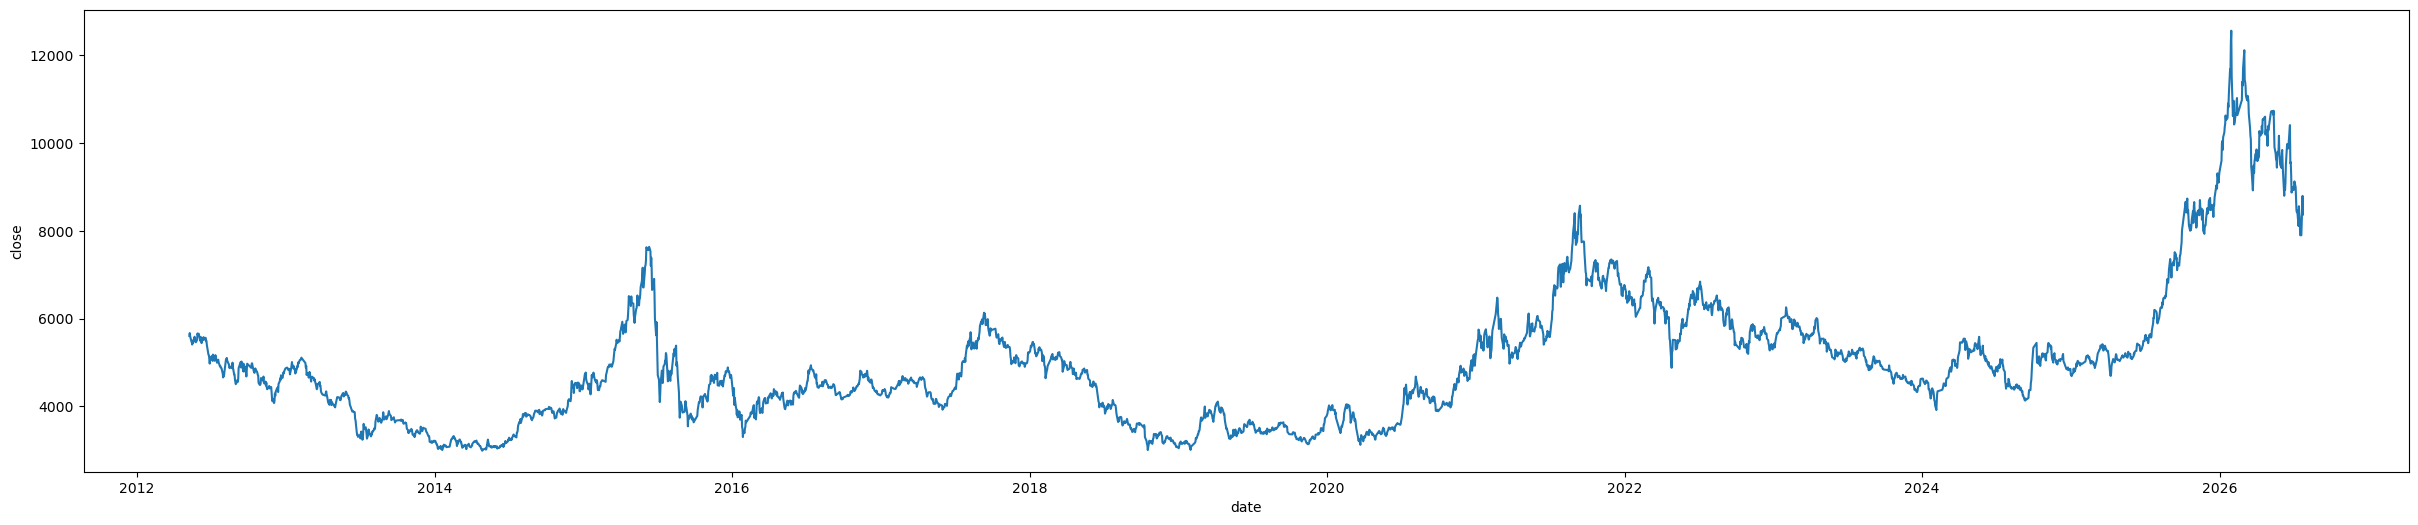

In [20]:
plt.figure(figsize=(30,6))
sns.lineplot(data=metal_index,y='close',x=metal_index.index)

下面要根据 [黄金概念指数编撰规则](../../doc/黄金概念指数编撰规则.md) 来编辑自己的黄金股票指数 , 采用两种方法  
1. 等式值加权  
2. 根据扣非净利润加权

In [23]:
gold_company_dic = {
    "紫金矿业": "sh601899",
    "山东黄金": "sh600547",
    "中金黄金": "sh600489",
    "赤峰黄金": "sh600988",
    "山金国际": "sz000975",
    "湖南黄金": "sz002155",
    "西部黄金": "sh601069",
    "恒邦股份": "sz002237",
    "四川黄金": "sz001337",
    "招金黄金": "sz000506",
}

stock_data = {}

for name , code in gold_company_dic.items():
    df = ak.stock_zh_a_daily(symbol=code,start_date='2012-05-01',end_date='2026-07-24')
    df['date'] = pd.to_datetime(df["date"])
    df.set_index(df["date"])
    stock_data[name] = df
    print(f'{name}下载完成')

紫金矿业下载完成
山东黄金下载完成
中金黄金下载完成
赤峰黄金下载完成
山金国际下载完成
湖南黄金下载完成
西部黄金下载完成
恒邦股份下载完成
四川黄金下载完成
招金黄金下载完成


In [38]:
stock_data['西部黄金'].head()

,date,open,high,low,close,volume,amount,outstanding_share,turnover
0,2015-01-22,4.28,5.14,4.28,5.14,128500.0,658770.0,126000000.0,0.001020
1,2015-01-23,5.65,5.65,5.65,5.65,47521.0,268494.0,126000000.0,0.000377
2,2015-01-26,6.22,6.22,6.22,6.22,27000.0,167940.0,126000000.0,0.000214
3,2015-01-27,6.84,6.84,6.84,6.84,45200.0,309168.0,126000000.0,0.000359
4,2015-01-28,7.52,7.52,7.52,7.52,88900.0,668528.0,126000000.0,0.000706


In [40]:
stock_data['四川黄金'].head()

,date,open,high,low,close,volume,amount,outstanding_share,turnover
0,2023-03-03,8.51,10.21,8.51,10.21,1044208.0,10614709.0,60000000.0,0.017403
1,2023-03-06,11.23,11.23,11.23,11.23,201805.0,2266270.0,60000000.0,0.003363
2,2023-03-07,12.35,12.35,12.35,12.35,176475.0,2179466.0,60000000.0,0.002941
3,2023-03-08,13.59,13.59,13.59,13.59,154662.0,2101857.0,60000000.0,0.002578
4,2023-03-09,14.95,14.95,14.95,14.95,220929.0,3302889.0,60000000.0,0.003682


经检验,两者上市时间较短,一个为150亿一个为200亿,为了保证数据尽可能时间长,把这两者删除掉

In [42]:
del stock_data['四川黄金']
del stock_data['西部黄金']

将这些数据存储下来,便于以后使用

In [26]:
import pickle

In [58]:
with open('../../data/stock_data.pkl','wb') as f:
    pickle.dump(stock_data,f)

In [59]:
with open('../../data/stock_data.pkl','rb') as f:
    stock_data = pickle.load(f)

### 方法一 等权重加权

In [66]:
stock_data_set = pd.DataFrame({name:df['close'] for name, df in stock_data.items() })
display(stock_data_set)

,紫金矿业,山东黄金,中金黄金,赤峰黄金,山金国际,湖南黄金,恒邦股份,招金黄金
0,4.40,36.20,23.79,14.44,5.63,28.42,38.89,10.65
1,4.37,35.89,23.40,13.72,6.19,28.40,38.39,10.80
2,4.38,36.12,23.40,14.20,6.81,29.36,39.18,10.74
3,4.39,36.57,23.78,14.39,7.49,28.90,39.99,10.56
4,4.38,36.10,23.59,14.93,8.24,27.93,39.29,10.55
...,...,...,...,...,...,...,...,...
3435,NaN,NaN,20.78,NaN,NaN,NaN,12.33,NaN
3436,NaN,NaN,22.11,NaN,NaN,NaN,12.89,NaN
3437,NaN,NaN,22.45,NaN,NaN,NaN,13.12,NaN
3438,NaN,NaN,21.36,NaN,NaN,NaN,13.24,NaN


看来我没有把不同的数据统一用日期设置为索引,导致错误对齐的发生.下面应该先用循环将时间设置为索引,再进行新的数据构建

In [67]:
for name,df in stock_data.items():
    df['date'] = pd.to_datetime(df['date'])
    stock_data[name] = df.set_index('date')

stock_data_set = pd.DataFrame({name:df['close'] for name,df in stock_data.items()})

In [68]:
display(stock_data_set)

,紫金矿业,山东黄金,中金黄金,赤峰黄金,山金国际,湖南黄金,恒邦股份,招金黄金
date,,,,,,,,
2012-05-02,4.40,36.20,23.79,14.44,NaN,28.42,38.89,10.65
2012-05-03,4.37,35.89,23.40,13.72,NaN,28.40,38.39,10.80
2012-05-04,4.38,36.12,23.40,14.20,5.63,NaN,39.18,10.74
2012-05-07,4.39,36.57,23.78,14.39,6.19,29.36,39.99,10.56
2012-05-08,4.38,36.10,23.59,14.93,6.81,28.90,39.29,10.55
...,...,...,...,...,...,...,...,...
2026-07-20,29.35,24.42,19.53,32.25,19.00,20.83,12.33,11.15
2026-07-21,30.21,25.87,20.78,35.48,20.47,22.23,12.89,11.84
2026-07-22,32.20,27.40,22.11,38.22,22.52,23.01,13.12,13.02


In [74]:
stock_data_set_pctchange = stock_data_set.pct_change()
stock_data_set_pctchange =stock_data_set_pctchange.fillna(0)
display(stock_data_set_pctchange)

/var/folders/nm/mph7gkl57w5_rd8w9fgp9c5r0000gp/T/ipykernel_20445/1348759280.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  stock_data_set_pctchange = stock_data_set.pct_change()


,紫金矿业,山东黄金,中金黄金,赤峰黄金,山金国际,湖南黄金,恒邦股份,招金黄金
date,,,,,,,,
2012-05-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-05-03,-0.006818,-0.008564,-0.016393,-0.049861,0.000000,-0.000704,-0.012857,0.014085
2012-05-04,0.002288,0.006408,0.000000,0.034985,0.000000,0.000000,0.020578,-0.005556
2012-05-07,0.002283,0.012458,0.016239,0.013380,0.099467,0.033803,0.020674,-0.016760
2012-05-08,-0.002278,-0.012852,-0.007990,0.037526,0.100162,-0.015668,-0.017504,-0.000947
...,...,...,...,...,...,...,...,...
2026-07-20,0.034908,0.027778,0.024659,0.016068,0.024259,0.003372,0.009828,-0.017621
2026-07-21,0.029302,0.059378,0.064004,0.100155,0.077368,0.067211,0.045418,0.061883
2026-07-22,0.065872,0.059142,0.064004,0.077227,0.100147,0.035088,0.017843,0.099662


In [75]:
stock_data_set_pctchange_mean = stock_data_set_pctchange.mean(axis=1)
display(stock_data_set_pctchange_mean)

date
2012-05-02    0.000000
2012-05-03   -0.010139
2012-05-04    0.007338
2012-05-07    0.022693
2012-05-08    0.010056
                ...   
2026-07-20    0.015406
2026-07-21    0.063090
2026-07-22    0.064873
2026-07-23    0.013141
2026-07-24   -0.055400
Length: 3459, dtype: float64

In [79]:
equal_weight_stock_index = (1+stock_data_set_pctchange_mean).cumprod() * 1000 #这里以1000作为基准值
display(equal_weight_stock_index)

date
2012-05-02    1000.000000
2012-05-03     989.860918
2012-05-04     997.124634
2012-05-07    1019.752529
2012-05-08    1030.007264
                 ...     
2026-07-20    2365.429630
2026-07-21    2514.664139
2026-07-22    2677.798032
2026-07-23    2712.986274
2026-07-24    2562.686772
Length: 3459, dtype: float64

<Axes: xlabel='date'>

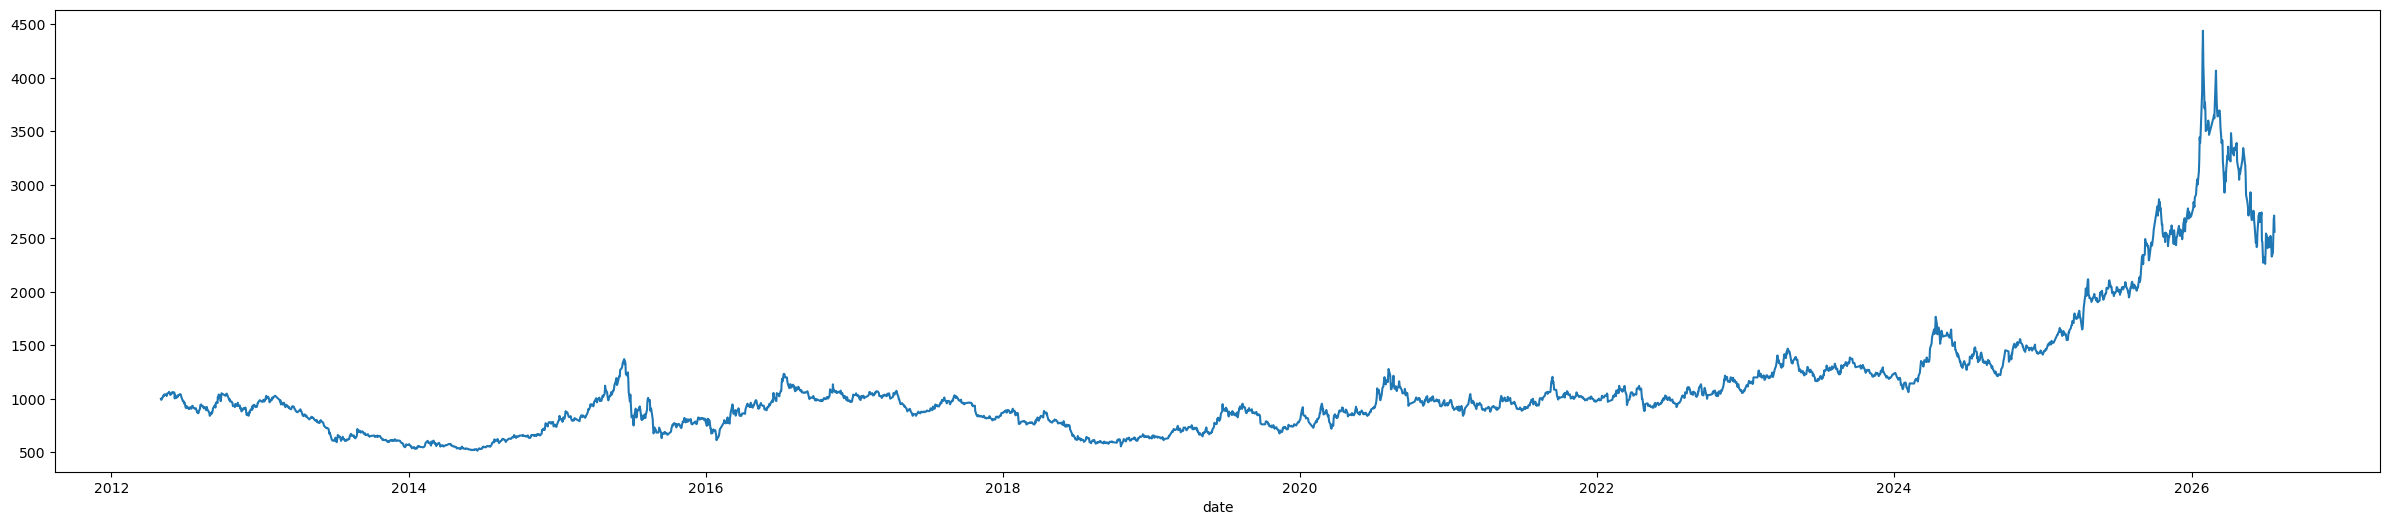

In [80]:
plt.figure(figsize=(30,6))
sns.lineplot(equal_weight_stock_index)

### 方法二 扣非净利润加权

根据2025年的年报数据,我将扣非净利润作为基本面的判断,不以市值等可能脱离实际价值的数值作为判断标准.我假设2026年等近年的竞争格局保持不变.先整理这些股票的财务数据

In [ ]:
zijin_mining = ak.stock_financial_analysis_indicator('601899',start_year='2012')
zijin_mining.columns

  0%|          | 0/15 [00:00<?, ?it/s]

Index(['日期', '摊薄每股收益(元)', '加权每股收益(元)', '每股收益_调整后(元)', '扣除非经常性损益后的每股收益(元)',
       '每股净资产_调整前(元)', '每股净资产_调整后(元)', '每股经营性现金流(元)', '每股资本公积金(元)',
       '每股未分配利润(元)', '调整后的每股净资产(元)', '总资产利润率(%)', '主营业务利润率(%)', '总资产净利润率(%)',
       '成本费用利润率(%)', '营业利润率(%)', '主营业务成本率(%)', '销售净利率(%)', '股本报酬率(%)',
       '净资产报酬率(%)', '资产报酬率(%)', '销售毛利率(%)', '三项费用比重', '非主营比重', '主营利润比重',
       '股息发放率(%)', '投资收益率(%)', '主营业务利润(元)', '净资产收益率(%)', '加权净资产收益率(%)',
       '扣除非经常性损益后的净利润(元)', '主营业务收入增长率(%)', '净利润增长率(%)', '净资产增长率(%)',
       '总资产增长率(%)', '应收账款周转率(次)', '应收账款周转天数(天)', '存货周转天数(天)', '存货周转率(次)',
       '固定资产周转率(次)', '总资产周转率(次)', '总资产周转天数(天)', '流动资产周转率(次)', '流动资产周转天数(天)',
       '股东权益周转率(次)', '流动比率', '速动比率', '现金比率(%)', '利息支付倍数', '长期债务与营运资金比率(%)',
       '股东权益比率(%)', '长期负债比率(%)', '股东权益与固定资产比率(%)', '负债与所有者权益比率(%)',
       '长期资产与长期资金比率(%)', '资本化比率(%)', '固定资产净值率(%)', '资本固定化比率(%)', '产权比率(%)',
       '清算价值比率(%)', '固定资产比重(%)', '资产负债率(%)', '总资产(元)', '经营现金净流量对销售收入比率(%)',
       '资产的经营现金流量回报率(%)', '经营现金净流量与净利润的比率(%)', 

In [ ]:

zijin_mining[['日期','扣除非经常性损益后的净利润(元)']]

,日期,扣除非经常性损益后的净利润(元)
0,2012-03-31,NaN
1,2012-06-30,2.471903e+09
2,2012-09-30,NaN
3,2012-12-31,5.142168e+09
4,2013-03-31,NaN
5,2013-06-30,1.278439e+09
6,2013-09-30,1.885643e+09
7,2013-12-31,2.416425e+09
8,2014-03-31,5.631383e+08
9,2014-06-30,1.178599e+09


In [ ]:
#这一步首先算出各个公司的权重,获取他们的2025年的扣非净利润
weight_gold_company_dic = {
        "紫金矿业": "601899",
        "山东黄金": "600547",
        "中金黄金": "600489",
        "赤峰黄金": "600988",
        "山金国际": "000975",
        "湖南黄金": "002155",
        "恒邦股份": "002237",
        "招金黄金": "000506",
}

if "weight_stock_data" not in dir():
    weight_stock_data = {}
for name , code in weight_gold_company_dic.items():
    if name in weight_stock_data and not weight_stock_data[name].empty:
        print(f'已经存在有数据,自动跳过')
        continue
    df = ak.stock_financial_analysis_indicator(code ,start_year='2025')
    df = df.set_index('日期')
    weight_stock_data[name] = df
    print(f'{name}25 年年份数据下载完成')

weight_stock_data['紫金矿业'].head()

已经存在有数据,自动跳过
已经存在有数据,自动跳过
已经存在有数据,自动跳过
已经存在有数据,自动跳过
已经存在有数据,自动跳过
已经存在有数据,自动跳过
已经存在有数据,自动跳过


  0%|          | 0/2 [00:00<?, ?it/s]

招金黄金25 年年份数据下载完成


,摊薄每股收益(元),加权每股收益(元),每股收益_调整后(元),扣除非经常性损益后的每股收益(元),每股净资产_调整前(元),每股净资产_调整后(元),每股经营性现金流(元),每股资本公积金(元),每股未分配利润(元),调整后的每股净资产(元),...,2-3年以内应收帐款(元),3年以内应收帐款(元),1年以内预付货款(元),1-2年以内预付货款(元),2-3年以内预付货款(元),3年以内预付货款(元),1年以内其它应收款(元),1-2年以内其它应收款(元),2-3年以内其它应收款(元),3年以内其它应收款(元)
日期,,,,,,,,,,,,,,,,,,,,,
2025-03-31,0.4690,0.376,0.383,NaN,6.9869,54.9077,0.4714,1.0814,3.8819,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-30,1.0778,0.860,0.877,0.814,7.2197,53.4563,1.0847,0.7944,4.0957,NaN,...,527244795.0,NaN,NaN,2.993806e+08,131179509.0,NaN,NaN,927211555.0,227032258.0,NaN
2025-09-30,1.7195,1.396,1.425,NaN,8.5398,63.7050,1.9606,1.3794,4.4263,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31,2.4003,1.910,1.950,1.910,9.3278,69.7796,2.8368,1.4425,4.9476,NaN,...,609749993.0,NaN,NaN,1.462690e+09,113543371.0,NaN,NaN,807155918.0,285947893.0,NaN
2026-03-31,0.9464,0.736,0.755,NaN,10.0569,75.3711,1.0467,1.4487,5.7025,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> #### 默认下载下来的数据集可能是datetime类型,而非pandas的datetime64类型,每次下载数据,读取数据前,应该要转换成标准的时间格式

In [135]:
for name in weight_stock_data:
    weight_stock_data[name].index = pd.to_datetime(weight_stock_data[name].index)

In [138]:
weight_stock_data_2025_profit = {
    name : df.loc['2025-12-31','扣除非经常性损益后的净利润(元)']
    for name ,df in weight_stock_data.items()
    if '2025-12-31' in df.index       
}

weight_stock_data_2025_profit = pd.Series(weight_stock_data_2025_profit)
display(weight_stock_data_2025_profit)

紫金矿业    5.072351e+10
山东黄金    4.993016e+09
中金黄金    5.771585e+09
赤峰黄金    3.058272e+09
山金国际    3.031393e+09
湖南黄金    1.526905e+09
恒邦股份    7.623439e+08
招金黄金    8.793842e+07
dtype: float64

In [141]:
weight_stock_data_2025_result = weight_stock_data_2025_profit/weight_stock_data_2025_profit.sum()
display(weight_stock_data_2025_result)

紫金矿业    0.725088
山东黄金    0.071375
中金黄金    0.082504
赤峰黄金    0.043718
山金国际    0.043333
湖南黄金    0.021827
恒邦股份    0.010898
招金黄金    0.001257
dtype: float64

这个紫金矿业的扣非净利润仍然占到了72%以上,而其他的企业在黄金开采的主营上面,确实是远远落后的.我选取的公司基本已经覆盖了主要的上市公司,但是其权重这样算,是否与市值加权没有太大区别?  

In [208]:
#这一步首先算出各个公司的总市值
cap_gold_company_dic = {
        "紫金矿业": "601899",
        "山东黄金": "600547",
        "中金黄金": "600489",
        "赤峰黄金": "600988",
        "山金国际": "000975",
        "湖南黄金": "002155",
        "恒邦股份": "002237",
        "招金黄金": "000506",
}

if "cap_stock_data" not in dir():
    cap_stock_data = {}
for name , code in cap_gold_company_dic.items():
    if name in cap_stock_data and not cap_stock_data[name].empty:
        print(f'已经存在有数据,自动跳过')
        continue
    df = ak.stock_individual_info_em(code)
    cap_stock_data[name] = df
    print(f'{name}25 年年份数据下载完成')

cap_stock_data['紫金矿业'].head()

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

这里接口暂时没法使用了,我人工统计了一下

In [214]:
cap_stock_data = {
    '紫金矿业':8378.3,
    '山东黄金':1196,
    '中金黄金':1035,
    "赤峰黄金":693.5,
    "山金国际": 604.4,
    "湖南黄金": 346.6,
    "恒邦股份": 178.9,
    "招金黄金": 111.9,
    }
cap_stock_data = pd.Series(cap_stock_data)
display(cap_stock_data)

紫金矿业    8378.3
山东黄金    1196.0
中金黄金    1035.0
赤峰黄金     693.5
山金国际     604.4
湖南黄金     346.6
恒邦股份     178.9
招金黄金     111.9
dtype: float64

In [215]:
cap_stock_data_result = cap_stock_data / cap_stock_data.sum()
display(cap_stock_data_result)

紫金矿业    0.667881
山东黄金    0.095340
中金黄金    0.082506
赤峰黄金    0.055283
山金国际    0.048180
湖南黄金    0.027629
恒邦股份    0.014261
招金黄金    0.008920
dtype: float64

结论是按照营业能力来说,紫金矿业的占比更大,如果单纯按照市值计算(2026/7/24日计算),则紫金矿业的占比相对更小.占比将近67%.

In [221]:
weight_stock_data_index = stock_data_set_pctchange * weight_stock_data_2025_result
display(weight_stock_data_index)


,紫金矿业,山东黄金,中金黄金,赤峰黄金,山金国际,湖南黄金,恒邦股份,招金黄金
date,,,,,,,,
2012-05-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-05-03,-0.004944,-0.000611,-0.001353,-0.002180,0.000000,-0.000015,-0.000140,0.000018
2012-05-04,0.001659,0.000457,0.000000,0.001529,0.000000,0.000000,0.000224,-0.000007
2012-05-07,0.001655,0.000889,0.001340,0.000585,0.004310,0.000738,0.000225,-0.000021
2012-05-08,-0.001652,-0.000917,-0.000659,0.001641,0.004340,-0.000342,-0.000191,-0.000001
...,...,...,...,...,...,...,...,...
2026-07-20,0.025312,0.001983,0.002034,0.000702,0.001051,0.000074,0.000107,-0.000022
2026-07-21,0.021246,0.004238,0.005281,0.004379,0.003353,0.001467,0.000495,0.000078
2026-07-22,0.047763,0.004221,0.005281,0.003376,0.004340,0.000766,0.000194,0.000125


In [222]:
weight_stock_data_index = weight_stock_data_index.sum(axis=1)
display(weight_stock_data_index)

date
2012-05-02    0.000000
2012-05-03   -0.009225
2012-05-04    0.003863
2012-05-07    0.009722
2012-05-08    0.002219
                ...   
2026-07-20    0.031241
2026-07-21    0.040536
2026-07-22    0.066066
2026-07-23    0.022368
2026-07-24   -0.048199
Length: 3459, dtype: float64

In [223]:
weight_stock_data_index = (1+weight_stock_data_index).cumprod()*1000 #1000作为基准值
display(weight_stock_data_index)

date
2012-05-02    1000.000000
2012-05-03     990.774873
2012-05-04     994.602630
2012-05-07    1004.271898
2012-05-08    1006.500162
                 ...     
2026-07-20    5123.428722
2026-07-21    5331.111009
2026-07-22    5683.318623
2026-07-23    5810.440569
2026-07-24    5530.385078
Length: 3459, dtype: float64

<Axes: xlabel='date'>

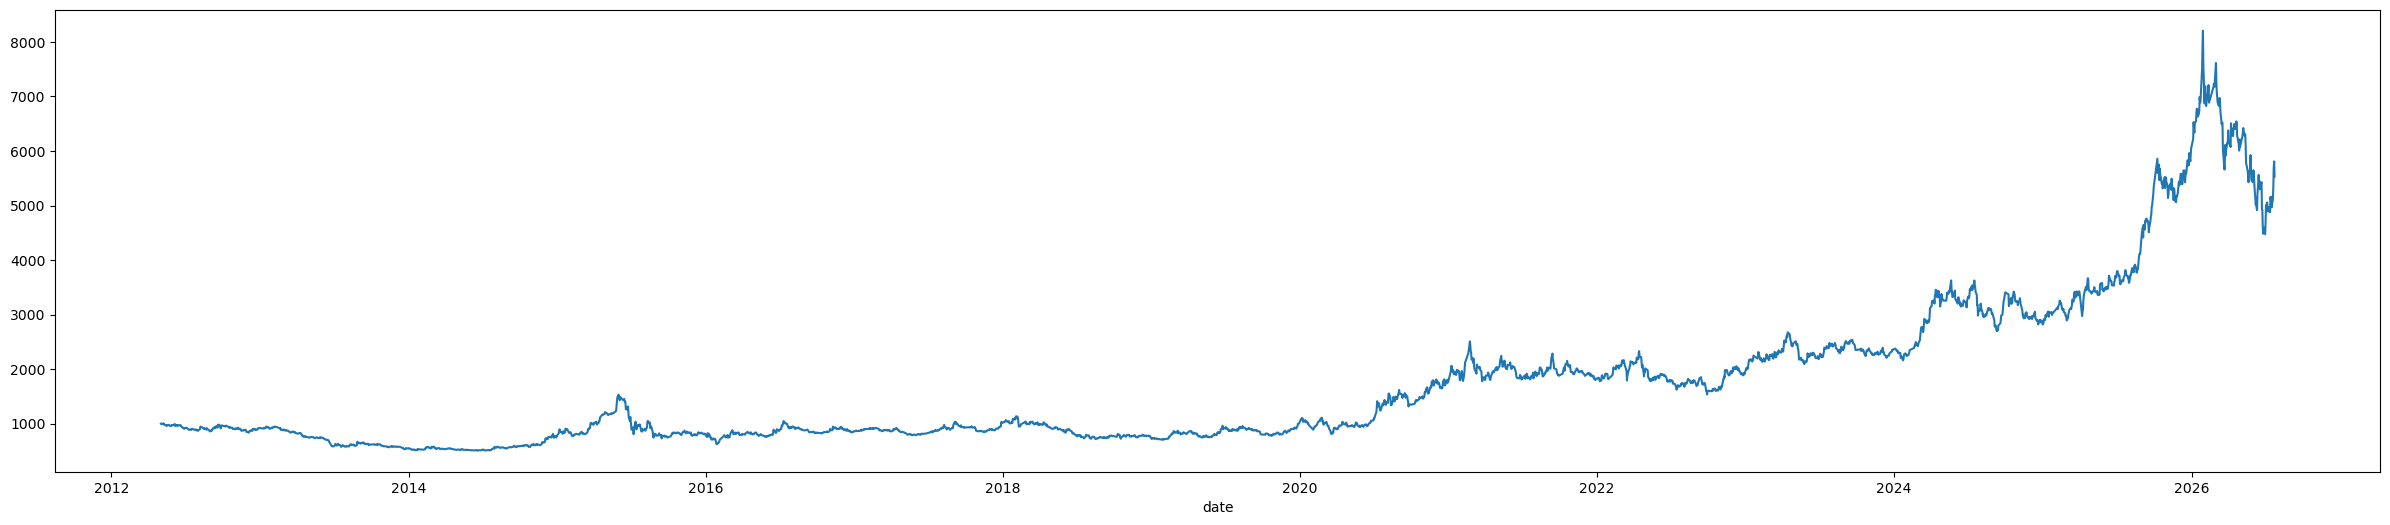

In [226]:
plt.figure(figsize=(30,6))
sns.lineplot(weight_stock_data_index)

In [227]:
cap_stock_data_index = cap_stock_data_result * stock_data_set_pctchange
display(cap_stock_data_index)

,紫金矿业,山东黄金,中金黄金,赤峰黄金,山金国际,湖南黄金,恒邦股份,招金黄金
date,,,,,,,,
2012-05-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-05-03,-0.004554,-0.000816,-0.001353,-0.002756,0.000000,-0.000019,-0.000183,0.000126
2012-05-04,0.001528,0.000611,0.000000,0.001934,0.000000,0.000000,0.000293,-0.000050
2012-05-07,0.001525,0.001188,0.001340,0.000740,0.004792,0.000934,0.000295,-0.000150
2012-05-08,-0.001521,-0.001225,-0.000659,0.002075,0.004826,-0.000433,-0.000250,-0.000008
...,...,...,...,...,...,...,...,...
2026-07-20,0.023315,0.002648,0.002035,0.000888,0.001169,0.000093,0.000140,-0.000157
2026-07-21,0.019570,0.005661,0.005281,0.005537,0.003728,0.001857,0.000648,0.000552
2026-07-22,0.043995,0.005639,0.005281,0.004269,0.004825,0.000969,0.000254,0.000889


In [228]:
cap_stock_data_index = cap_stock_data_index.sum(axis=1)
cap_stock_data_index = (1+cap_stock_data_index).cumprod() * 1000 #以1000作为基础值
display(cap_stock_data_index)

date
2012-05-02    1000.000000
2012-05-03     990.443629
2012-05-04     994.719688
2012-05-07    1005.327165
2012-05-08    1008.145576
                 ...     
2026-07-20    4827.178200
2026-07-21    5033.940032
2026-07-22    5366.790961
2026-07-23    5481.074967
2026-07-24    5213.366389
Length: 3459, dtype: float64

<Axes: xlabel='date'>

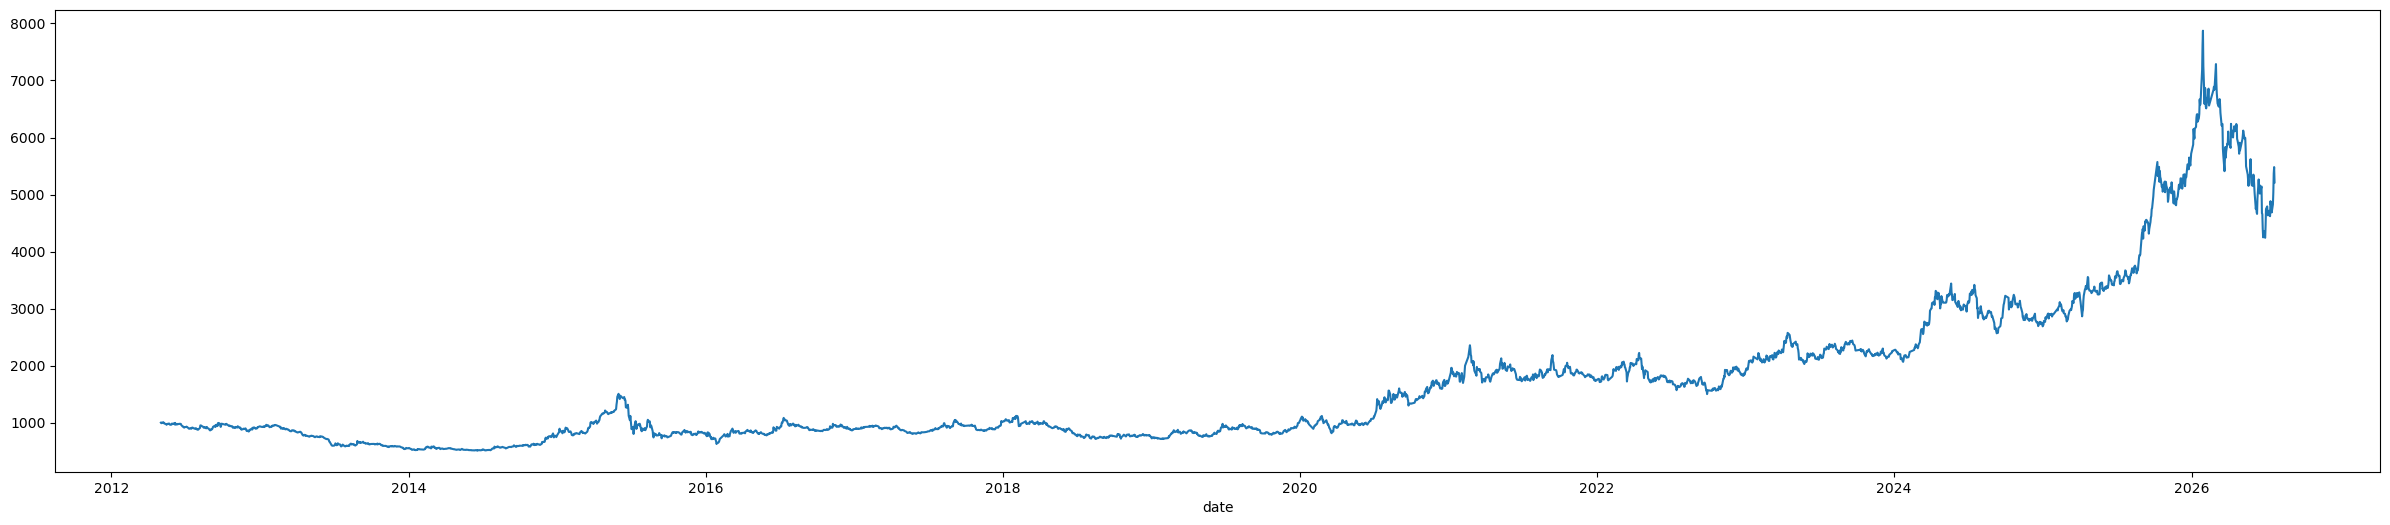

In [229]:
plt.figure(figsize=(30,6))
sns.lineplot(cap_stock_data_index)

---
把所有的数据保存为pkl,用于不同笔记之间数据交换

In [236]:
all_index_dic = {
    'A_500':A500_index,
    'CSI_300':CSI_300_index,
    'metal':metal_index,
    'weight':weight_stock_data_index,
    'cap':cap_stock_data_index,
    'equal':equal_weight_stock_index,
}

with open('../../src/pickle/all_index_dic.pkl','wb') as f:
    pickle.dump(all_index_dic,f)